# Chile Tickets: Weekly Forecast — SARIMA tuning
**Rules we're holding ourselves to:**
1. Every forecast for week *W* is made by a model that has seen data only through the Sunday before week *W* — never refit or peeked using anything from week *W* onward.
2. Model/parameter **selection** (SARIMA order, GLM features, ensemble weight) uses only an older 25-week window (the **TUNE** set). The most recent 25 weeks (**HOLDOUT**) are touched exactly once, at the end, to report a number — never used to pick anything.
3. If the tuned config doesn't reach 10% MAPE on HOLDOUT, we report that honestly rather than re-tuning against it or cherry-picking a subset of weeks.

### 1. Imports

In [2]:
import warnings, itertools
import numpy as np
import pandas as pd
import holidays
import matplotlib.pyplot as plt
from sklearn.linear_model import PoissonRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

In [3]:
DATA_PATH = "/Users/vaibhavi/Downloads/ticket_full.csv"

df = pd.read_csv(DATA_PATH, usecols=["contact_create_dt"], parse_dates=["contact_create_dt"])

daily = df.groupby(df["contact_create_dt"].dt.normalize()).size()
daily = daily.reindex(pd.date_range(daily.index.min(), daily.index.max()), fill_value=0)

print(f"{len(daily)} days | {daily.index.min().date()} to {daily.index.max().date()} | mean {daily.mean():.1f}/day")

613 days | 2024-12-26 to 2026-08-30 | mean 152.6/day


In [4]:
df.shape

(93539, 1)

In [5]:
def mape(actual, pred):
    actual, pred = np.asarray(actual, float), np.asarray(pred, float) # MAPE formula 
    return np.mean(np.abs(pred - actual) / actual) * 100 #har week ka |forecast − actual| ÷ actual, phir average, phir ×100."

def weekly_actual(week_ends):
    return np.array([daily.loc[e - pd.Timedelta(days=6):e].sum() for e in week_ends]) ## for each Sunday: sum the 7 days (Mon-Sun) = actual weekly tickets

def walk_forward(week_ends, forecast_fn):
    # history stops at the Sunday before the week being forecast
    return np.array([forecast_fn(daily.loc[:e - pd.Timedelta(days=7)]).sum() for e in week_ends])

## for each Sunday e: use only data up to the previous Sunday (e - 7 days),
    # forecast the next 7 days, and add them up = forecast weekly tickets
    #walk_forward = har Sunday ko "aaj" maano, us din tak ka data model ko do, aur usse agle hafte ka forecast lo.

In [6]:
def sarimax_forecast(history, order, seasonal_order):
    model = SARIMAX(np.log1p(history), order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    return np.expm1(model.forecast(7))

#history → log se chhota → model pattern seekhe → 7 din forecast → log ulta → ticket counts

In [7]:
# purpose # Purpose: turn each day into numeric features so the GLM can learn ticket volume.
# Features: weekday, Chile holidays (day / day before / day after),
#           recent volume (last 7 / 28 days), same weekday over the last 4 weeks, optional trend. basically too give GLM clues

cl_holidays = holidays.Chile(years=range(2024, 2028)) #this is a library tht helps us to dinf the holidyas public holidays 

def is_holiday(dates):
    return np.array([int(d.date() in cl_holidays) for d in dates]) # here an array is there of all holidyas

def make_features(s, trend=False, avg_long=28):#clues ki table
    X = pd.DataFrame(index=s.index)
    for d in range(7):
        X[f"dow{d}"] = (s.index.dayofweek == d).astype(int)# weekdays outcome
    X["holiday"]      = is_holiday(s.index) #f for everyholdiday 1 or 0
    X["holiday_prev"] = is_holiday(s.index - pd.Timedelta(days=1))
    X["holiday_next"] = is_holiday(s.index + pd.Timedelta(days=1))

    last_sunday = s.index - pd.to_timedelta(s.index.dayofweek + 1, unit="D")
    X["log_avg7"]           = np.log(s.rolling(7).mean().reindex(last_sunday).values + 1)
    X[f"log_avg{avg_long}"] = np.log(s.rolling(avg_long).mean().reindex(last_sunday).values + 1)
    X["log_same_dow"]       = np.log(sum(s.shift(k) for k in (7, 14, 21, 28)) / 4 + 1)
    if trend:
        X["t"] = (last_sunday - s.index.min()).days / 365.0
    return X

In [8]:
# Purpose: train a Poisson GLM (Generalized Linear Model) on all days up to the last Sunday
# and forecast the next 7 days (Mon-Sun).
def glm_forecast(history, **feature_kwargs):
    future = pd.date_range(history.index[-1] + pd.Timedelta(days=1), periods=7)   # next 7 days
    s = history.reindex(history.index.append(future))                              # extend series (future = empty)
    X = make_features(s, **feature_kwargs)                                         # feature table for all days
    train = X.loc[history.index].dropna()                                          # past days only, drop rows with missing features

    model = make_pipeline(StandardScaler(), PoissonRegressor(alpha=0.01, max_iter=1000))   # scale features -> Poisson GLM
    model.fit(train, history.loc[train.index])                                     # learn from past features + actual tickets
    return pd.Series(model.predict(X.loc[future]), index=future)                   # predict the next 7 days

In [9]:
def last_weeks(n, skip=0):
    sundays = daily.index[daily.index.dayofweek == 6]
    return sundays[len(sundays) - skip - n : len(sundays) - skip]

TUNE_ENDS = last_weeks(25, skip=25)
HOLD_ENDS = last_weeks(25)

tune_actual = weekly_actual(TUNE_ENDS)
hold_actual = weekly_actual(HOLD_ENDS)

print("TUNE   :", TUNE_ENDS.min().date(), "to", TUNE_ENDS.max().date())
print("HOLDOUT:", HOLD_ENDS.min().date(), "to", HOLD_ENDS.max().date())

# holdout is basically test data 
#tune is validation data 

TUNE   : 2025-09-21 to 2026-03-08
HOLDOUT: 2026-03-15 to 2026-08-30


In [10]:
orders          = [(1,0,1), (2,0,1), (1,1,1), (2,1,1), (0,1,1)]
seasonal_orders = [(1,1,1,7), (0,1,1,7), (1,1,0,7), (2,1,1,7)]

sarima_preds = {}
for order, sorder in itertools.product(orders, seasonal_orders):
    try:
        sarima_preds[(order, sorder)] = walk_forward(TUNE_ENDS, lambda h: sarimax_forecast(h, order, sorder))
    except Exception:
        pass   # skip combos that fail to fit

sarima_scores = {k: mape(tune_actual, p) for k, p in sarima_preds.items()}
best_sarima = min(sarima_scores, key=sarima_scores.get)

pd.DataFrame(sarima_scores.items(), columns=["(order, seasonal_order)", "tune_mape"]).sort_values("tune_mape").head(5)

# Purpose Purpose: SARIMAX ke 20 alag settings try karo, har ek ko TUNE ke 25 hafton pe test karo, aur jiska MAPE sabse kam ho use chun lo.

,"(order, seasonal_order)",tune_mape
9,"((1, 1, 1), (0, 1, 1, 7))",12.950421
8,"((1, 1, 1), (1, 1, 1, 7))",13.002773
11,"((1, 1, 1), (2, 1, 1, 7))",13.035310
12,"((2, 1, 1), (1, 1, 1, 7))",13.158511
13,"((2, 1, 1), (0, 1, 1, 7))",13.201692


In [11]:
glm_variants = {
    "GLM_base":      dict(trend=False, avg_long=28),
    "GLM_trend":     dict(trend=True,  avg_long=28),
    "GLM_avg14":     dict(trend=False, avg_long=14),
    "GLM_trend_a14": dict(trend=True,  avg_long=14),
}

glm_preds  = {n: walk_forward(TUNE_ENDS, lambda h: glm_forecast(h, **kw)) for n, kw in glm_variants.items()}
glm_scores = {n: mape(tune_actual, p) for n, p in glm_preds.items()}
best_glm   = min(glm_scores, key=glm_scores.get)

pd.Series(glm_scores, name="tune_mape").sort_values()

GLM_base         10.831869
GLM_trend        10.837880
GLM_avg14        10.899895
GLM_trend_a14    11.082850
Name: tune_mape, dtype: float64

In [12]:
#Ye block dono models ka combo (mix) banata hai, aur tay karta hai ki kis model ko kitna weigh ya dependece dena hai.

weights = np.arange(0, 1.01, 0.05)
blend   = [mape(tune_actual, w * glm_preds[best_glm] + (1 - w) * sarima_preds[best_sarima]) for w in weights]
best_w  = weights[int(np.argmin(blend))]

print(f"SARIMAX : {best_sarima[0]} x {best_sarima[1]}  (TUNE MAPE {sarima_scores[best_sarima]:.2f}%)")
print(f"GLM     : {best_glm}  (TUNE MAPE {glm_scores[best_glm]:.2f}%)")
print(f"Weight  : {best_w:.2f} GLM / {1 - best_w:.2f} SARIMAX  (TUNE MAPE {min(blend):.2f}%)")


#Option	TUNE MAPE	Kaisa?
#Sirf SARIMAX	12.95%	sabse kharab
#Sirf GLM	10.83%	achha
#Mix (75% GLM + 25% SARIMAX)	10.46%	sabse achha
#per Ye TUNE ka score hai, final nahi.

SARIMAX : (1, 1, 1) x (0, 1, 1, 7)  (TUNE MAPE 12.95%)
GLM     : GLM_base  (TUNE MAPE 10.83%)
Weight  : 0.75 GLM / 0.25 SARIMAX  (TUNE MAPE 10.46%)


In [13]:
## Purpose: final test on the HOLDOUT weeks (run once, no re-tuning).
# Compare GLM, tuned/default SARIMAX, a naive 4-week average, and the tuned ensemble by MAPE.

best_order, best_sorder = best_sarima

holdout = pd.DataFrame({
    "actual":          hold_actual,
    "GLM":             walk_forward(HOLD_ENDS, lambda h: glm_forecast(h, **glm_variants[best_glm])),
    "SARIMAX_tuned":   walk_forward(HOLD_ENDS, lambda h: sarimax_forecast(h, best_order, best_sorder)),
    "SARIMAX_default": walk_forward(HOLD_ENDS, lambda h: sarimax_forecast(h, (1,0,1), (1,1,1,7))),
    "Avg_last_4w":     [daily.loc[:e - pd.Timedelta(days=7)].iloc[-28:].sum() / 4 for e in HOLD_ENDS],
}, index=HOLD_ENDS)
holdout["Ensemble_tuned"] = best_w * holdout["GLM"] + (1 - best_w) * holdout["SARIMAX_tuned"]

(holdout.drop(columns="actual")
        .apply(lambda p: mape(holdout["actual"], p))
        .round(2).sort_values().rename("HOLDOUT MAPE (%)"))

Ensemble_tuned     12.64
GLM                13.01
Avg_last_4w        13.34
SARIMAX_tuned      13.42
SARIMAX_default    14.78
Name: HOLDOUT MAPE (%), dtype: float64

In [14]:
# FINAL MODEL Ensemble_tuned (12.64%). weight 75/25 Ensemble = 0.75 × GLM ka forecast + 0.25 × SARIMAX_tuned ka forecast

In [15]:
err = ((holdout["Ensemble_tuned"] - holdout["actual"]).abs() / holdout["actual"] * 100).sort_values(ascending=False)
worst = err.index[:2]

print("Worst weeks (abs % error):")
print(err.head(5).round(1).to_string())

rest = holdout.drop(worst)
print(f"\nMAPE without the 2 worst weeks: {mape(rest['actual'], rest['Ensemble_tuned']):.2f}%  (diagnostic, not the result)")

Worst weeks (abs % error):
2026-05-10    44.0
2026-07-26    30.3
2026-05-17    25.1
2026-03-22    22.2
2026-07-19    17.1

MAPE without the 2 worst weeks: 10.51%  (diagnostic, not the result)


In [16]:
for wk in worst:
    print(f"\nDaily tickets, week ending {wk.date()}:")
    print(daily.loc[wk - pd.Timedelta(days=6):wk].to_string())


Daily tickets, week ending 2026-05-10:
2026-05-04    191
2026-05-05    150
2026-05-06    897
2026-05-07    152
2026-05-08    150
2026-05-09    128
2026-05-10     72
Freq: D

Daily tickets, week ending 2026-07-26:
2026-07-20    352
2026-07-21    415
2026-07-22    330
2026-07-23    302
2026-07-24    284
2026-07-25    267
2026-07-26    128
Freq: D


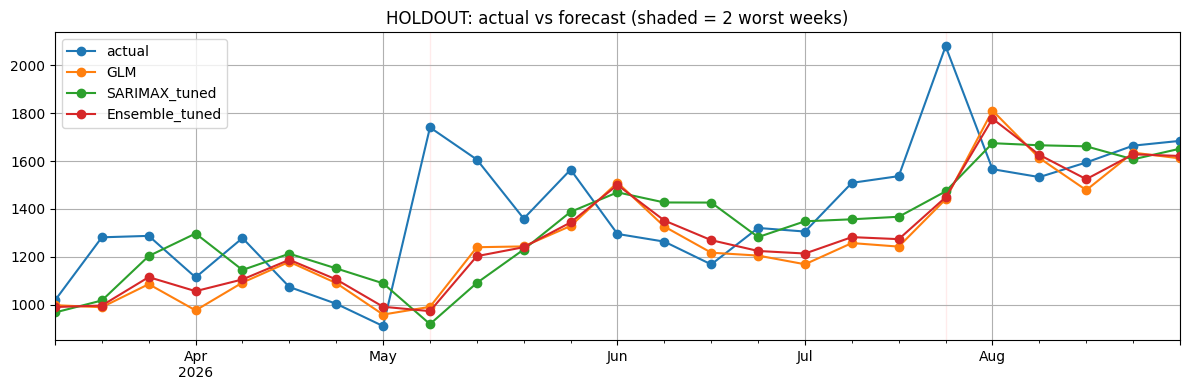

In [17]:
ax = holdout[["actual", "GLM", "SARIMAX_tuned", "Ensemble_tuned"]].plot(figsize=(12, 4), marker="o", grid=True)
for wk in worst:
    ax.axvspan(wk - pd.Timedelta(days=6), wk, color="red", alpha=0.08)
ax.set_title("HOLDOUT: actual vs forecast (shaded = 2 worst weeks)")
plt.tight_layout()
plt.show()

In [18]:
abs_err = (holdout["Ensemble_tuned"] - holdout["actual"]).abs()   # error in tickets

print(f"Max error: {err.max():.1f}%  ({abs_err[err.idxmax()]:.0f} tickets) | week ending {err.idxmax().date()}")
print(f"Min error: {err.min():.1f}%  ({abs_err[err.idxmin()]:.0f} tickets) | week ending {err.idxmin().date()}")
print(f"Median error: {err.median():.1f}% | Mean error (MAPE): {err.mean():.2f}%")

Max error: 44.0%  (766 tickets) | week ending 2026-05-10
Min error: 2.2%  (36 tickets) | week ending 2026-08-23
Median error: 10.1% | Mean error (MAPE): 12.64%


Q1  If train test was there then what was the requirement of holdout and tune ?
Ans HOLDOUT wahi hai jo test hota hai. Naya hissa sirf TUNE hai. Aur TUNE isliye chahiye kyunki hum bahut saare options mein se best chun rahe hain.
    Kyuki hum ensemble learning use ki like 2 models ilsiye.

Q2  Which models are used? 
Ans GLM (generalized linear model + SARIMA). 75% GLM and 25% SARIMA)

Q3   Which GLM used?
Ans. GLM (Generalized Linear Model) is a regression model built for targets that aren't bell-shaped, such as counts. Ours is a Poisson GLM, because tickets per day are counts.

Q4  What is the final MAPE? Is it daily or weekly?
Ans 12.64% (Weeklu)

Q5  How we decided the ratio?
Ans GLM ka hissa 0% se 100% tak 5% ke kadam mein try kiya, aur jis mix ne practice weeks (TUNE) pe sabse kam error diya wahi liya. Wo 75% GLM aur 25% SARIMA nikla.

In [19]:
complexity and resource 

NameError: name 'complexity' is not defined

In [20]:
%pip install xgboost lightgbm prophet


[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [24]:
# Helper for ML models: same clues as the GLM (make_features), any scikit-learn style model
def ml_forecast(history, model, **feature_kwargs):
    future = pd.date_range(history.index[-1] + pd.Timedelta(days=1), periods=7)
    s = history.reindex(history.index.append(future))
    X = make_features(s, **feature_kwargs)
    train = X.loc[history.index].dropna()

    model.fit(train, np.log1p(history.loc[train.index]))            # learn on log(tickets)
    return pd.Series(np.expm1(model.predict(X.loc[future])), index=future)

In [25]:
sar_tune = sarima_preds[best_sarima]                 # best SARIMA forecasts, TUNE weeks
sar_hold = holdout["SARIMAX_tuned"].values           # best SARIMA forecasts, HOLDOUT weeks

glm_hold = {n: walk_forward(HOLD_ENDS, lambda h: glm_forecast(h, **kw)) for n, kw in glm_variants.items()}
avg_tune = np.array([daily.loc[:e - pd.Timedelta(days=7)].iloc[-28:].sum() / 4 for e in TUNE_ENDS])
avg_hold = holdout["Avg_last_4w"].values

results = []
def combo(name, partner_tune, partner_hold):
    ws = np.round(np.arange(0, 1.01, 0.05), 2)
    tune_scores = [mape(tune_actual, w * partner_tune + (1 - w) * sar_tune) for w in ws]
    w = ws[int(np.argmin(tune_scores))]                                  # partner weight, chosen on TUNE
    tune_mape = min(tune_scores)
    hold_mape = mape(hold_actual, w * partner_hold + (1 - w) * sar_hold)
    results.append({"combo": name, "w_partner": w, "TUNE_MAPE": tune_mape, "HOLD_MAPE": hold_mape})
    print(f"{name:26s} partner weight {w:.2f} | TUNE {tune_mape:.2f}% | HOLDOUT {hold_mape:.2f}%")

In [28]:
combo("SARIMA + XGBoost", xgb_tune, xgb_hold)

SARIMA + XGBoost           partner weight 0.55 | TUNE 11.35% | HOLDOUT 13.56%


In [27]:
from xgboost import XGBRegressor

def make_xgb():
    return XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8,
                        random_state=0, verbosity=0)

xgb_tune = walk_forward(TUNE_ENDS, lambda h: ml_forecast(h, make_xgb()))
xgb_hold = walk_forward(HOLD_ENDS, lambda h: ml_forecast(h, make_xgb()))
combo("SARIMA + XGBoost", xgb_tune, xgb_hold)

SARIMA + XGBoost           partner weight 0.55 | TUNE 11.35% | HOLDOUT 13.56%


In [35]:
from lightgbm import LGBMRegressor

def make_lgbm():
    return LGBMRegressor(n_estimators=300, num_leaves=8, learning_rate=0.05, subsample=0.8,
                         subsample_freq=1, random_state=0, verbose=-1)

lgbm_tune = walk_forward(TUNE_ENDS, lambda h: ml_forecast(h, make_lgbm()))
lgbm_hold = walk_forward(HOLD_ENDS, lambda h: ml_forecast(h, make_lgbm()))
combo("SARIMA + LightGBM", lgbm_tune, lgbm_hold)

SARIMA + LightGBM          partner weight 0.30 | TUNE 12.29% | HOLDOUT 12.28%


In [36]:
from sklearn.linear_model import Ridge

def make_ridge():
    return make_pipeline(StandardScaler(), Ridge(alpha=1.0))

ridge_tune = walk_forward(TUNE_ENDS, lambda h: ml_forecast(h, make_ridge(), trend=True))
ridge_hold = walk_forward(HOLD_ENDS, lambda h: ml_forecast(h, make_ridge(), trend=True))
combo("SARIMA + Ridge", ridge_tune, ridge_hold)

SARIMA + Ridge             partner weight 1.00 | TUNE 11.43% | HOLDOUT 13.02%


In [37]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

def ets_forecast(history):
    model = ExponentialSmoothing(np.log1p(history), trend="add", damped_trend=True,
                                 seasonal="add", seasonal_periods=7).fit()
    return np.expm1(model.forecast(7))

ets_tune = walk_forward(TUNE_ENDS, ets_forecast)
ets_hold = walk_forward(HOLD_ENDS, ets_forecast)
combo("SARIMA + ETS (Holt-Winters)", ets_tune, ets_hold)

SARIMA + ETS (Holt-Winters) partner weight 0.00 | TUNE 12.95% | HOLDOUT 13.42%


In [ ]:
# SARIMA + GLM_base	0.75	10.46%	12.64%	Original Ensemble
# 2	SARIMA + XGBoost	0.55	11.35%	13.56%	
# 3	SARIMA + Ridge	1.00	11.43%	13.02%	
# 4	SARIMA + LightGBM	0.30	12.29%	12.28%
# 5	SARIMA + ETS (Holt-Winters)	0.00	12.95%	13.42%	

In [29]:
import pickle
import pandas as pd
import numpy as np
from sklearn.linear_model import PoissonRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX

# --- Refit GLM once on ALL of `daily`, using the winning config ---
final_glm_kwargs = glm_variants[best_glm]

future7 = pd.date_range(daily.index[-1] + pd.Timedelta(days=1), periods=7)
s_full  = daily.reindex(daily.index.append(future7))
X_full  = make_features(s_full, **final_glm_kwargs)
train_X = X_full.loc[daily.index].dropna()
train_y = daily.loc[train_X.index]

final_glm = make_pipeline(StandardScaler(), PoissonRegressor(alpha=0.01, max_iter=1000))
final_glm.fit(train_X, train_y)

# --- Refit SARIMAX once on ALL of `daily`, using the winning order ---
final_sarimax = SARIMAX(np.log1p(daily), order=best_order, seasonal_order=best_sorder,
                         enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

# --- Save everything needed to rebuild the ensemble forecast, in one .pkl ---
with open("ensemble_tuned_model.pkl", "wb") as f:
    pickle.dump({
        "glm":             final_glm,
        "sarimax":         final_sarimax,
        "best_w":          best_w,
        "glm_kwargs":      final_glm_kwargs,
        "sarimax_order":   best_order,
        "sarimax_sorder":  best_sorder,
        "last_train_date": daily.index[-1],
        "full_series":     daily,
    }, f)

print(f"Saved ensemble_tuned_model.pkl (trained through {daily.index[-1].date()})")

Saved ensemble_tuned_model.pkl (trained through 2026-08-30)
